In [1]:
# drive a bağlanma
from google.colab import drive
drive.mount('/content/drive')

# problemli paketleri kaldır
!pip uninstall -y huggingface-hub transformers langchain-huggingface

# hepsini tek komutta, uyumlu sürümlerle kur
!pip install "huggingface-hub<1.0.0" "transformers>=4.37.0" "langchain-huggingface" "qwen-vl-utils" "accelerate" "bitsandbytes" "langchain-community" "langchain-core" "chromadb" "sentence-transformers"

print("Kurulum tamamlandı.")

Mounted at /content/drive
Found existing installation: huggingface-hub 0.36.0
Uninstalling huggingface-hub-0.36.0:
  Successfully uninstalled huggingface-hub-0.36.0
Found existing installation: transformers 4.57.3
Uninstalling transformers-4.57.3:
  Successfully uninstalled transformers-4.57.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [2]:
import os
import json
import torch
import glob
import re
from google.colab import drive
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

# drive bağla
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

json_path = "/content/drive/MyDrive/FoodData_Central_foundation_food_json_2025-12-18.json" # Kendi yolunu kontrol et
dataset_path = "/content/drive/MyDrive/test/"

In [3]:
def setup_rag_database(json_file_path):
    print(f"Veritabanı yükleniyor: {json_file_path}")
    if not os.path.exists(json_file_path):
        print("HATA: JSON bulunamadı.")
        return None

    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    rag_documents = []
    # veri setine göre doğru listeyi bulma
    foods = data.get("FoundationFoods", [])
    if not foods and "SRLegacyFoods" in data:
        foods = data["SRLegacyFoods"]

    print(f"{len(foods)} ürün taranıyor...")

    for food in foods:
        name = food.get("description", "Bilinmeyen")

        # güvenli veri cekme
        nutrients = {}
        for n in food.get("foodNutrients", []):
            # 'nutrient' anahtarı yoksa boş sözlük dön, 'name' yoksa boş string dön
            nut_name = n.get("nutrient", {}).get("name", "").lower()
            # 'amount' yoksa 0 kabul et
            amount = n.get("amount", 0)
            nutrients[nut_name] = amount

        # besin değerlerini sözlükten çek (safe get)
        cal = next((v for k,v in nutrients.items() if "energy" in k), None)
        prot = next((v for k,v in nutrients.items() if "protein" in k), 0)
        fat = next((v for k,v in nutrients.items() if "lipid" in k or "fat" in k), 0)
        carb = next((v for k,v in nutrients.items() if "carbohydrate" in k), 0)

        # sadece kalorisi olanları ekle
        if cal is not None:
            content = f"Yemek: {name}. Enerji: {cal} kcal. Protein: {prot} g. Yag: {fat} g. Karbonhidrat: {carb} g."
            # metadata içine sayısal değerleri de ekliyoruz ki ilerde sıralama yapabilelim
            rag_documents.append(Document(page_content=content, metadata={"name": name, "cal": float(cal)}))

    if not rag_documents:
        print("HATA: Hiçbir veri çıkarılamadı. JSON yapısını kontrol et.")
        return None

    print(f"{len(rag_documents)} yemek başarıyla işlendi.")
    print("Vektör veritabanı (ChromaDB) oluşturuluyor...")

    emb_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    db = Chroma.from_documents(documents=rag_documents, embedding=emb_model)
    return db.as_retriever(search_kwargs={"k": 2}) # en iyi 2 sonucu getir

# Global Retriever Nesnesi
retriever = setup_rag_database(json_path)

Veritabanı yükleniyor: /content/drive/MyDrive/FoodData_Central_foundation_food_json_2025-12-18.json
365 ürün taranıyor...
323 yemek başarıyla işlendi.
Vektör veritabanı (ChromaDB) oluşturuluyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [4]:
def load_model():
    print("Qwen2-VL Agent Modeli Başlatılıyor...")
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        "Qwen/Qwen2-VL-7B-Instruct",
        torch_dtype=torch.float16,
        device_map="auto",
    )
    processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-7B-Instruct")
    return model, processor

model, processor = load_model()

`torch_dtype` is deprecated! Use `dtype` instead!


Qwen2-VL Agent Modeli Başlatılıyor...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

In [5]:
class FoodAgentTools:
    def __init__(self, model, processor, retriever):
        self.model = model
        self.processor = processor
        self.retriever = retriever
        self.device = model.device

    def identify_foods(self, image_path):
        """Görseldeki TÜM yemekleri tespit edip liste olarak döner."""
        print("   TOOL: [Multi-Detection] -> Tabaktaki tüm yemekler taranıyor...")

        # prompt'u "liste yap" şeklinde güncelledik
        prompt = "Identify all different food items in this image. Return them as a comma-separated list (e.g. 'Rice, Chicken, Salad'). Do not write sentences."

        msgs = [{"role": "user", "content": [{"type": "image", "image": image_path}, {"type": "text", "text": prompt}]}]
        text_input = self.processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = self.processor(text=[text_input], images=process_vision_info(msgs)[0], padding=True, return_tensors="pt").to(self.device)

        output = self.model.generate(**inputs, max_new_tokens=100)
        res_text = self.processor.batch_decode(output, skip_special_tokens=True)[0].split("assistant\n")[-1].strip()

        # virgülle ayrılmış metni python listesine çevir
        food_list = [x.strip() for x in res_text.split(',')]
        return food_list

    def estimate_weight(self, image_path, food_name):
        """Spesifik bir yemeğin gramajını tahmin eder."""
        # Prompt artık "Resimdeki ŞU YEMEĞE odaklan" diyor
        print(f"   TOOL: [Weight] -> '{food_name}' için gramaj bakılıyor...")
        prompt = f"Look at the {food_name} in this image. Estimate the weight of ONLY the {food_name} portion in grams. Provide ONLY the number."

        msgs = [{"role": "user", "content": [{"type": "image", "image": image_path}, {"type": "text", "text": prompt}]}]
        text_input = self.processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = self.processor(text=[text_input], images=process_vision_info(msgs)[0], padding=True, return_tensors="pt").to(self.device)

        output = self.model.generate(**inputs, max_new_tokens=20)
        res_text = self.processor.batch_decode(output, skip_special_tokens=True)[0].split("assistant\n")[-1].strip()

        match = re.search(r"(\d+)", res_text)
        return float(match.group(1)) if match else 100.0 # Bulamazsa varsayılan 100g

    def lookup_nutrition(self, food_name):
        """RAG araması yapar."""
        docs = self.retriever.invoke(food_name)
        if docs:
            return docs[0].page_content, docs[0].metadata.get('cal', 50.0)
        return "Not found", 50.0 # Bulamazsa varsayılan 50 kcal

# Araçları yeniden başlat
tools = FoodAgentTools(model, processor, retriever)

In [11]:
class DietAgent:
    def __init__(self, tools):
        self.tools = tools

    def run(self, image_path):
        print(f"\nAJAN BAŞLATILDI (Çoklu Analiz Modu)")
        print("-" * 50)

        # yemekleri bul
        food_list = self.tools.identify_foods(image_path)
        print(f"AJAN GÖZLEMİ: Tespit edilenler -> {food_list}")

        plate_summary = []
        total_plate_calories = 0

        # her yemek için döngüye gir
        for food in food_list:
            if not food: continue # Boş gelirse atla
            print(f"\n   ANALİZ EDİLİYOR: {food.upper()}...")

            # gramaj tahmini
            weight = self.tools.estimate_weight(image_path, food)

            # besin degeri (rag)
            info_text, base_cal = self.tools.lookup_nutrition(food)

            # hesapla
            item_cal = (base_cal * weight) / 100
            total_plate_calories += item_cal

            # listeye ekle
            plate_summary.append({
                "name": food,
                "weight": weight,
                "cal": item_cal,
                "base": base_cal
            })
            print(f"      -> {weight:.0f}g, {item_cal:.0f} kcal hesaplandı.")

        # rapor
        print("-" * 50)
        print(f"TABAK ANALİZİ BİTTİ. TOPLAM: {total_plate_calories:.0f} kcal")

        return {
            "foods": plate_summary,
            "total_cal": total_plate_calories
        }

# görselleştirme
def visualize_multi_result(image_path, result):
    plt.figure(figsize=(14, 7))

    # Resim
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(image_path))
    plt.title(f"TABAK TOPLAMI: {result['total_cal']:.0f} kcal", fontsize=16, color='darkred', fontweight='bold')
    plt.axis('off')

    # Detaylı Liste
    plt.subplot(1, 2, 2)
    plt.axis('off')

    # başlık oluştur
    header = f"{'YEMEK':<20} {'GR':<8} {'KCAL':<8}\n" + "="*40 + "\n"
    body = ""

    # yemekleri listele
    for item in result['foods']:
        # isim uzunsa kısalt
        name = (item['name'][:18] + '..') if len(item['name']) > 18 else item['name']
        line = f"{name:<20} {item['weight']:<8.0f} {item['cal']:<8.0f}\n"
        body += line

    # alt toplam
    footer = "="*40 + f"\n{'TOPLAM':<20} {'-':<8} {result['total_cal']:.0f} kcal"

    full_text = "🥗 DETAYLI ANALİZ RAPORU\n\n" + header + body + footer

    # ekrana yazdır
    plt.text(0.05, 0.9, full_text, fontsize=12, family='monospace', va='top')
    plt.tight_layout()
    plt.show()

# ajanı güncelle
agent = DietAgent(tools)


AJAN BAŞLATILDI (Çoklu Analiz Modu)
--------------------------------------------------
   TOOL: [Multi-Detection] -> Tabaktaki tüm yemekler taranıyor...
AJAN GÖZLEMİ: Tespit edilenler -> ['Cucumber']

   ANALİZ EDİLİYOR: CUCUMBER...
   TOOL: [Weight] -> 'Cucumber' için gramaj bakılıyor...
      -> 100g, 16 kcal hesaplandı.
--------------------------------------------------
TABAK ANALİZİ BİTTİ. TOPLAM: 16 kcal


/tmp/ipython-input-1842377913.py:80: UserWarning: Glyph 129367 (\N{GREEN SALAD}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129367 (\N{GREEN SALAD}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


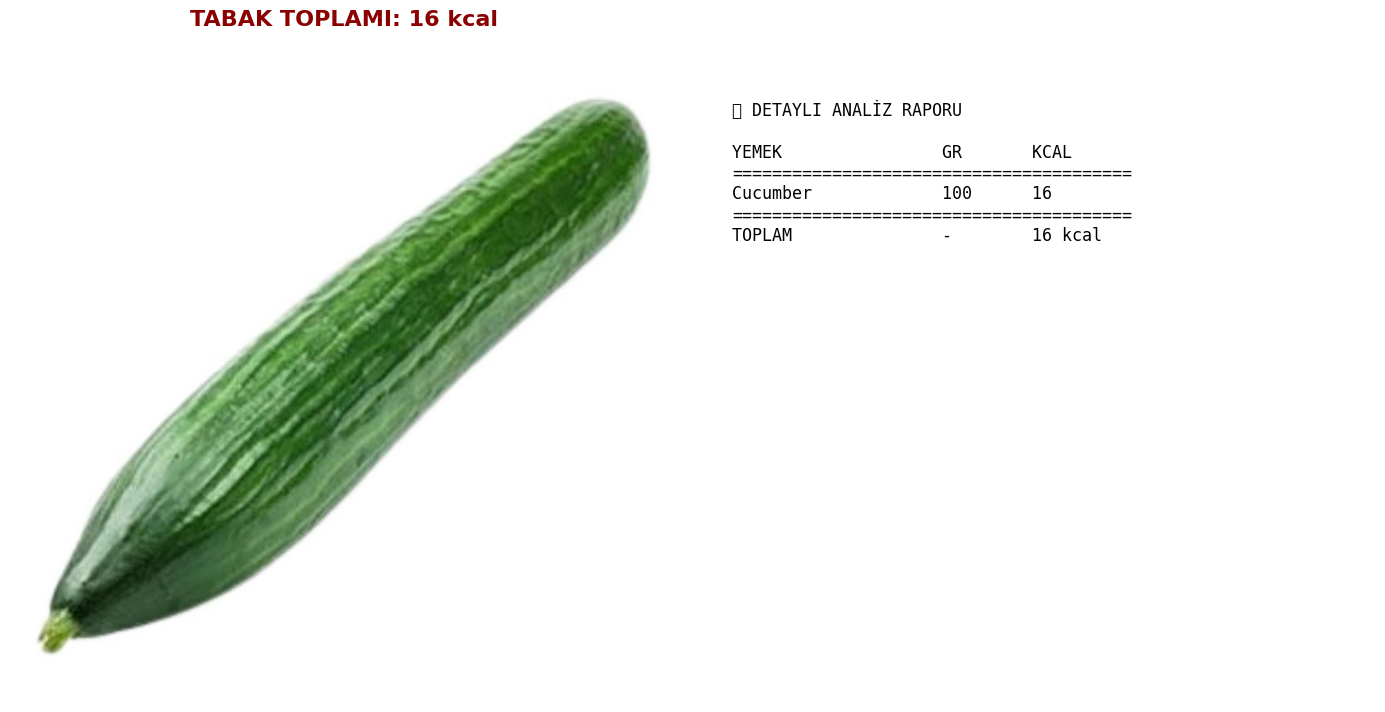


💬 DİYETİSYEN SOHBETİ BAŞLADI (Konu: 1 çeşit yemek, 16 kcal)
---------------------------------------------------


Output()

In [12]:
def start_multi_chat_real(result, model, processor):
    print(f"\n💬 DİYETİSYEN SOHBETİ BAŞLADI (Konu: {len(result['foods'])} çeşit yemek, {result['total_cal']:.0f} kcal)")
    print("---------------------------------------------------")

    # bağlam
    food_summary = ", ".join([f"{f['name']} ({f['weight']:.0f}g)" for f in result['foods']])

    # kısıtladım
    system_prompt = f"""
    Sen Türkçe konuşan profesyonel bir Diyetisyensin.

    MEVCUT DURUM:
    Kullanıcının tabağında şunlar var: {food_summary}.
    Toplam kalori: {result['total_cal']:.0f} kcal.

    KURALLAR:
    1. Asla kendini tekrar etme.
    2. Cevapların kısa, net ve anlaşılır olsun (maksimum 2-3 cümle).
    3. Kullanıcı "ekmek", "su" gibi genel şeyler sorarsa, tabağa bağlı kalmadan genel bilgi ver.
    4. Cümlelerin yarım kalmasın.
    """

    messages = [
        {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
        {"role": "user", "content": [{"type": "text", "text": "Analiz tamamlandı. Bekliyorum."}]}
    ]

    output_area = widgets.Output()
    input_box = widgets.Text(placeholder='Soru sor (Örn: Bu tabak sağlıklı mı?)', layout=widgets.Layout(width='70%'))
    send_btn = widgets.Button(description="Gönder", button_style='success')

    def generate_reply(user_input):
        messages.append({"role": "user", "content": [{"type": "text", "text": user_input}]})

        text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text_input], padding=True, return_tensors="pt").to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=150,     # Cevap çok uzamasın
                temperature=0.5,        # Düşürdük: Daha tutarlı cevaplar için (0.7 yerine 0.5)
                top_p=0.9,             # Anlamsız varyasyonları azalt
                repetition_penalty=1.2, # KRİTİK AYAR: Tekrarları engeller
                do_sample=True
            )

        generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        response = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]

        messages.append({"role": "assistant", "content": [{"type": "text", "text": response}]})
        return response

    def on_send(b):
        user_msg = input_box.value.strip()
        if not user_msg: return
        input_box.value = ""

        with output_area:
            print(f"\nSiz: {user_msg}")
            print("Yazıyor...", end="\r")

            try:
                reply = generate_reply(user_msg)
                print(f"Asistan: {reply}")
            except Exception as e:
                print(f"HATA: {e}")

    send_btn.on_click(on_send)
    input_box.on_submit(on_send)

    display(output_area)
    display(widgets.HBox([input_box, send_btn]))

    with output_area:
        print(f"Asistan: Analizime göre tabakta {food_summary} var. Sorularını bekliyorum!")

images = sorted(glob.glob(dataset_path + "*.jpg") + glob.glob(dataset_path + "*.png"))
if images:
    target_img = images[0]

    res_data = agent.run(target_img)
    visualize_multi_result(target_img, res_data)
else:
    print("Resim yok.")

# --- ÇALIŞTIR ---
if 'res_data' in locals() and res_data:
    start_multi_chat_real(res_data, model, processor)
else:
    print("Önce Hücre 6'yı çalıştır!")

Seçilen resim: dish_1556575124.png

AJAN BAŞLATILDI (Çoklu Analiz Modu)
--------------------------------------------------
   TOOL: [Multi-Detection] -> Tabaktaki tüm yemekler taranıyor...
AJAN GÖZLEMİ: Tespit edilenler -> ['Celery']

   ANALİZ EDİLİYOR: CELERY...
   TOOL: [Weight] -> 'Celery' için gramaj bakılıyor...
      -> 50g, 8 kcal hesaplandı.
--------------------------------------------------
TABAK ANALİZİ BİTTİ. TOPLAM: 8 kcal


/tmp/ipython-input-1842377913.py:80: UserWarning: Glyph 129367 (\N{GREEN SALAD}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()


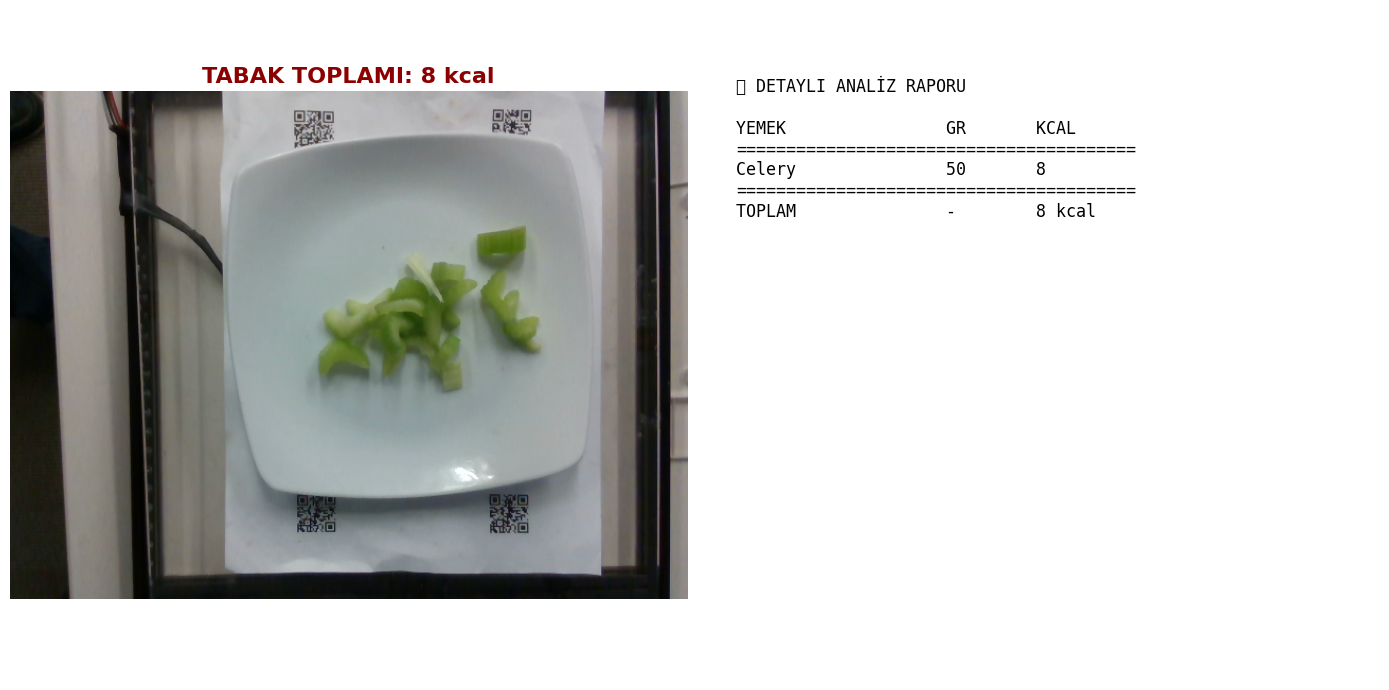


💬 DİYETİSYEN SOHBETİ BAŞLADI (Konu: 1 çeşit yemek, 8 kcal)
---------------------------------------------------


Output()

In [15]:
images = sorted(glob.glob(dataset_path + "*.jpg") + glob.glob(dataset_path + "*.png"))

if images:

    target_index = 5 if len(images) > 500 else 0
    target_img = images[target_index]

    print(f"Seçilen resim: {os.path.basename(target_img)}")
    res_data = agent.run(target_img)

    visualize_multi_result(target_img, res_data)

    start_multi_chat_real(res_data, model, processor)

else:
    print("Klasörde hiç resim bulunamadı.")